In [434]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
import random

In [435]:
X,y=make_classification(n_features=5,n_informative=5,n_clusters_per_class=1,n_redundant=0)

In [436]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

In [437]:
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.098424,1.711668,0.211519,1.451532,-1.721206,0
1,-0.260258,-0.671296,0.509739,-1.475721,0.042589,0
2,1.493246,1.085166,-2.157835,0.782288,-0.666320,0
3,0.028504,1.164797,-1.813844,0.528098,-0.695480,0
4,1.293539,-2.545296,-1.033851,-1.974448,-2.191772,1


In [438]:
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [439]:
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [440]:
def combined_sampling(df,row_percent,col_percent):
  new_df=sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [441]:
df1 = sample_rows(df,0.1)

In [442]:
df2 = sample_rows(df,0.1)


In [443]:
df3 = sample_rows(df,0.1)


In [444]:
df1.shape ,df2.shape ,df3.shape

((10, 6), (10, 6), (10, 6))

In [445]:
from sklearn.tree import DecisionTreeClassifier

clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [446]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [447]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[3] <= 0.291\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.625, 0.5, '  False')]

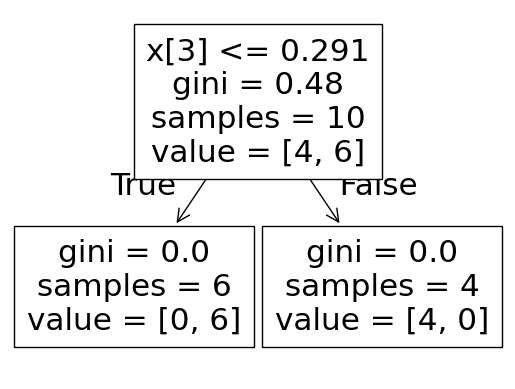

In [448]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[1] <= -0.703\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.625, 0.5, '  False')]

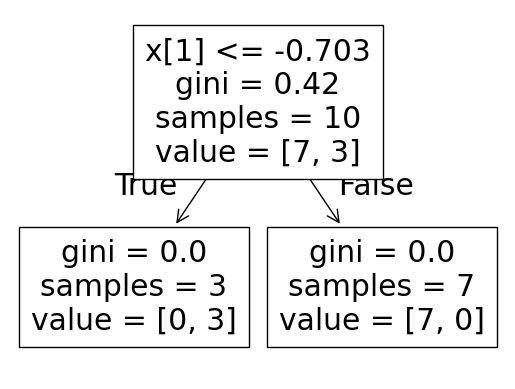

In [449]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[3] <= -0.311\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.625, 0.5, '  False')]

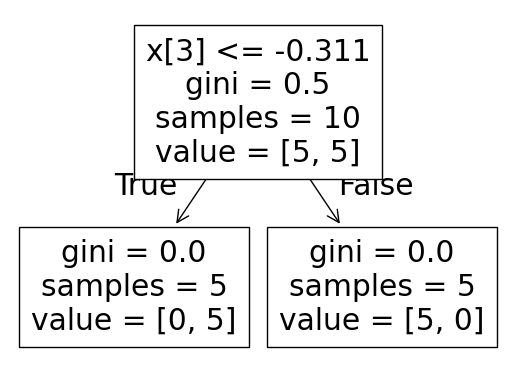

In [450]:
plot_tree(clf3)


In [451]:
clf1.predict(np.array([-0.383946	,-0.455449	,-1.558822	,-1.033667	,0.648231	]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [452]:
clf2.predict(np.array([-0.383946	,-0.455449	,-1.558822	,-1.033667	,0.648231	]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [453]:
clf3.predict(np.array([-0.383946	,-0.455449	,-1.558822	,-1.033667	,0.648231	]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

# Column Sampling

In [454]:
df1 = sample_features(df,0.5)

/tmp/ipykernel_1500/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [455]:
df2 = sample_features(df,0.5)

/tmp/ipykernel_1500/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [456]:
df3 = sample_features(df,0.5)

/tmp/ipykernel_1500/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [457]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[2] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [50, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [0, 50]'),
 Text(0.625, 0.5, '  False')]

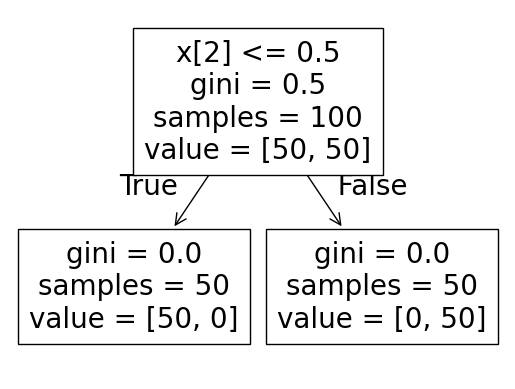

In [458]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[2] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [50, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [0, 50]'),
 Text(0.625, 0.5, '  False')]

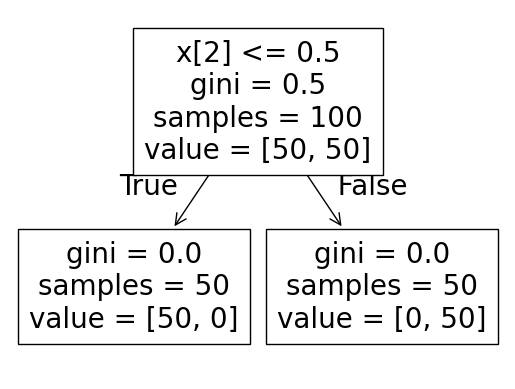

In [459]:
plot_tree(clf2)

[Text(0.5, 0.75, 'x[2] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [50, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 50\nvalue = [0, 50]'),
 Text(0.625, 0.5, '  False')]

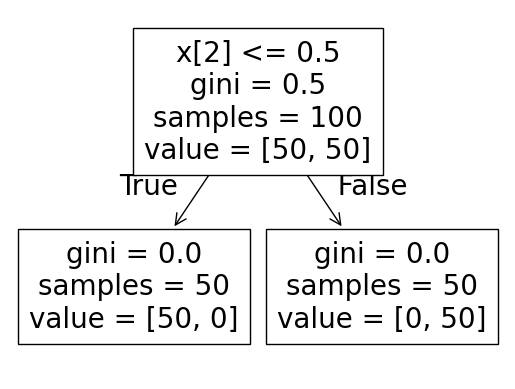

In [460]:
plot_tree(clf3)

In [463]:
clf1.predict(np.array([-0.383946	,-0.455449	,-1.558822]).reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [465]:
clf2.predict(np.array([-0.383946	,-0.455449	,-1.558822]).reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [466]:
clf3.predict(np.array([-0.383946	,-0.455449	,-1.558822]).reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [467]:
df1 = combined_sampling(df,0.5,0.5)


/tmp/ipykernel_1500/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [468]:
df2 = combined_sampling(df,0.5,0.5)


/tmp/ipykernel_1500/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [469]:
df3 = combined_sampling(df,0.5,0.5)


/tmp/ipykernel_1500/1824989938.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [470]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col1', 'target'], dtype='object')
Index(['col2', 'col5', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')


In [471]:

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()


In [472]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.6, 0.875, 'x[0] <= -0.076\ngini = 0.48\nsamples = 50\nvalue = [20, 30]'),
 Text(0.4, 0.625, 'x[0] <= -0.643\ngini = 0.062\nsamples = 31\nvalue = [1, 30]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 28\nvalue = [0, 28]'),
 Text(0.6, 0.375, 'x[0] <= -0.372\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.7, 0.75, '  False')]

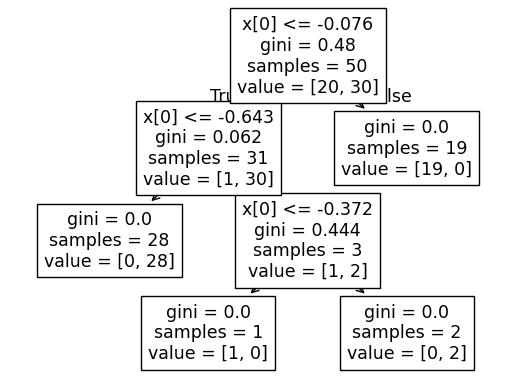

In [473]:
plot_tree(clf1)


[Text(0.4444444444444444, 0.9166666666666666, 'x[0] <= 0.336\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.3333333333333333, 0.75, 'x[0] <= -1.109\ngini = 0.285\nsamples = 29\nvalue = [5, 24]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[1] <= -0.304\ngini = 0.43\nsamples = 16\nvalue = [5, 11]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[1] <= -1.402\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6666666666666666, 0.4166666666666667, 'x[1] <= 0.532\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.5555555555555556, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.7777777777777778, 0.25, 'x[0] <= 0.174\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 

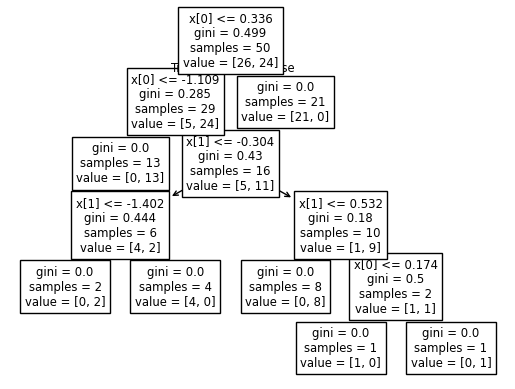

In [474]:
plot_tree(clf2)


[Text(0.5555555555555556, 0.9, 'x[0] <= 0.306\ngini = 0.48\nsamples = 50\nvalue = [30, 20]'),
 Text(0.3333333333333333, 0.7, 'x[1] <= 2.788\ngini = 0.32\nsamples = 35\nvalue = [28, 7]'),
 Text(0.4444444444444444, 0.8, 'True  '),
 Text(0.2222222222222222, 0.5, 'x[1] <= 1.285\ngini = 0.175\nsamples = 31\nvalue = [28, 3]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= -1.329\ngini = 0.444\nsamples = 9\nvalue = [6, 3]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.4444444444444444, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4444444444444444, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.7777777777777778, 0.7, 'x[0] <= 1.077\ngini = 0.231\nsamples = 15\nvalue = [2, 13]'),
 Text(0.6666666666666667, 0.8, '  False'),
 Text(0.6666666666666666, 0.5, 'x[0] <= 1.007\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.5555555555555556, 0.3, 'gini = 0.0\nsamples =

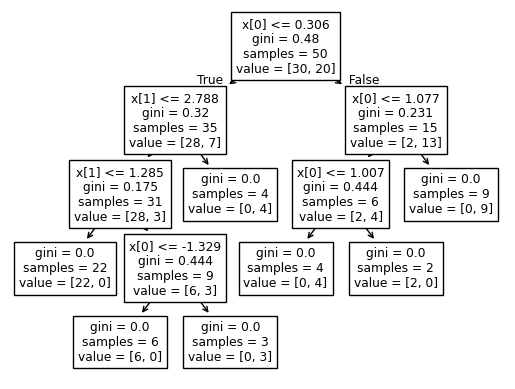

In [475]:
plot_tree(clf3)


In [476]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [477]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [478]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])